# WellCo — Uplift Modeling

**Goal**: Identify which test members will benefit most from outreach — i.e., maximize the number of churners *saved* per outreach contact.

**Approach**: Two uplift model architectures compared via cross-validation:

| Learner | Description | Strength |
|---------|-------------|----------|
| **S-learner** | Single model, `outreach` as a feature; uplift = predict(outreach=0) − predict(outreach=1) | Simple, uses full data |
| **T-learner** | Separate models for treated / control; uplift = T0(x) − T1(x) | Treatment groups modeled independently |

**Evaluation metrics**:
- **Qini coefficient** — area between Qini curve and random baseline; higher = better uplift ranking
- **AUUC** (Area Under Uplift Curve) — equivalent interpretation to Qini, framed as incremental churn reduction
- **Uplift@k** — actual churn rate difference in top-k% of predicted uplift group

**Note on features**: Same feature set as Phase 3 churn model. No v2 feature engineering needed —  
the uplift model learns treatment-feature interactions internally (S-learner) or via separate fits (T-learner).

**Outreach handling**: `outreach` is included as a feature only in the S-learner. For the T-learner,  
it is the treatment selector — excluded as a predictor.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

train = pd.read_parquet('train_features.parquet')
test  = pd.read_parquet('test_features.parquet')

FEAT_COLS = [c for c in train.columns if c not in ['member_id', 'churn', 'outreach']]
TARGET    = 'churn'
TREATMENT = 'outreach'

X_base = train[FEAT_COLS]          # features only (no outreach)
X_full = train[FEAT_COLS + [TREATMENT]]  # features + outreach (S-learner)
y      = train[TARGET]
w      = train[TREATMENT]

print(f"Train: {len(train):,} members | Features: {len(FEAT_COLS)} | + outreach for S-learner")
print(f"Treated: {w.sum():,} ({w.mean():.1%}) | Control: {(1-w).sum():,} ({(1-w).mean():.1%})")
print(f"Churn rate: {y.mean():.3f} | Outreach churn: {y[w==1].mean():.3f} | Control churn: {y[w==0].mean():.3f}")

Train: 10,000 members | Features: 35 | + outreach for S-learner
Treated: 3,984 (39.8%) | Control: 6,016 (60.2%)
Churn rate: 0.202 | Outreach churn: 0.194 | Control churn: 0.207


## 1. Uplift Evaluation Utilities

We implement the Qini curve and AUUC from scratch (no external uplift library required).

**Qini curve** (Radcliffe & Surry, 2007): Sort members by predicted uplift descending.  
At each fraction φ targeted, compute: `Q(φ) = cumulative_treated_churners − cumulative_control_churners × (N_treated / N_control)`  
The Qini coefficient is the area between this curve and the random-model diagonal.

In [2]:
def qini_curve(y_true, uplift_score, treatment):
    """Returns (x, qini_values) for plotting. x = fraction targeted."""
    y_true    = np.asarray(y_true)
    uplift_score = np.asarray(uplift_score)
    treatment = np.asarray(treatment)

    n   = len(y_true)
    n_t = treatment.sum()
    n_c = n - n_t

    order = np.argsort(-uplift_score)
    y_s = y_true[order]
    w_s = treatment[order]

    cum_y_t = np.cumsum(y_s * w_s)           # treated churners in top-k
    cum_y_c = np.cumsum(y_s * (1 - w_s))     # control churners in top-k

    qini = cum_y_t - cum_y_c * (n_t / n_c)   # Qini numerator
    x    = np.arange(1, n + 1) / n
    return x, qini


def qini_coefficient(y_true, uplift_score, treatment):
    """Area between Qini curve and random baseline."""
    x, qini = qini_curve(y_true, uplift_score, treatment)
    random  = np.linspace(0, qini[-1], len(qini))
    return float(np.trapz(qini - random, x))


def auuc(y_true, uplift_score, treatment):
    """Area under Qini curve (unnormalized; useful for absolute comparison)."""
    x, qini = qini_curve(y_true, uplift_score, treatment)
    return float(np.trapz(qini, x))


def uplift_at_k(y_true, uplift_score, treatment, k=0.3):
    """Uplift (churn rate difference) in the top-k fraction ranked by predicted uplift."""
    y_true    = np.asarray(y_true)
    treatment = np.asarray(treatment)
    n_top = max(1, int(len(y_true) * k))
    top   = np.argsort(-uplift_score)[:n_top]

    y_k = y_true[top]
    w_k = treatment[top]

    if w_k.sum() == 0 or (1 - w_k).sum() == 0:
        return np.nan

    return float(y_k[w_k == 0].mean() - y_k[w_k == 1].mean())


def random_qini(y_true, treatment):
    """Expected Qini of a model that ranks randomly."""
    n   = len(y_true)
    n_t = np.asarray(treatment).sum()
    n_c = n - n_t
    y   = np.asarray(y_true)
    w   = np.asarray(treatment)
    final_qini = y[w == 1].sum() - y[w == 0].sum() * (n_t / n_c)
    return np.linspace(0, final_qini, n), np.arange(1, n + 1) / n


print("Uplift metric utilities defined: qini_curve, qini_coefficient, auuc, uplift_at_k")

Uplift metric utilities defined: qini_curve, qini_coefficient, auuc, uplift_at_k


## 2. S-Learner Cross-Validation

One LightGBM model trained with `outreach` as a feature.  
OOF uplift = predict(X_val, outreach=0) − predict(X_val, outreach=1)

In [3]:
LGB_BASE = dict(
    objective='binary', metric='auc',
    n_estimators=1000, learning_rate=0.05,
    num_leaves=31, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    is_unbalance=True, random_state=42, verbose=-1,
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_uplift_s = np.zeros(len(train))
s_results = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_full, y)):
    X_tr, X_val = X_full.iloc[tr_idx], X_full.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],      y.iloc[val_idx]
    w_val       = w.iloc[val_idx]

    m = lgb.LGBMClassifier(**LGB_BASE)
    m.fit(X_tr, y_tr,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

    # Score with outreach flipped
    Xv0 = X_val.copy(); Xv0['outreach'] = 0
    Xv1 = X_val.copy(); Xv1['outreach'] = 1
    p0 = m.predict_proba(Xv0)[:, 1]
    p1 = m.predict_proba(Xv1)[:, 1]
    oof_uplift_s[val_idx] = p0 - p1

    qc = qini_coefficient(y_val.values, p0 - p1, w_val.values)
    au = auuc(y_val.values, p0 - p1, w_val.values)
    u20 = uplift_at_k(y_val.values, p0 - p1, w_val.values, k=0.20)
    u30 = uplift_at_k(y_val.values, p0 - p1, w_val.values, k=0.30)
    s_results.append(dict(fold=fold+1, qini=qc, auuc=au,
                          uplift_top20=u20, uplift_top30=u30,
                          best_iter=m.best_iteration_))
    print(f"Fold {fold+1}: Qini={qc:.4f}  AUUC={au:.4f}  Uplift@20%={u20:.4f}  Uplift@30%={u30:.4f}")

s_res = pd.DataFrame(s_results)
print(f"\nS-learner CV summary:")
print(f"  Mean Qini:      {s_res.qini.mean():.4f} ± {s_res.qini.std():.4f}")
print(f"  Mean AUUC:      {s_res.auuc.mean():.4f} ± {s_res.auuc.std():.4f}")
print(f"  Mean Uplift@20: {s_res.uplift_top20.mean():.4f}")
print(f"  Mean Uplift@30: {s_res.uplift_top30.mean():.4f}")

oof_qini_s = qini_coefficient(y.values, oof_uplift_s, w.values)
print(f"\n  OOF Qini (full): {oof_qini_s:.4f}")

/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini - random, x))
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini, x))


Fold 1: Qini=2.5703  AUUC=-4.3563  Uplift@20%=0.0061  Uplift@30%=0.0206


/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini - random, x))
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini, x))


Fold 2: Qini=-12.2565  AUUC=-15.6558  Uplift@20%=0.1054  Uplift@30%=0.0434


/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini - random, x))
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini, x))


Fold 3: Qini=-9.8495  AUUC=-10.4960  Uplift@20%=0.0453  Uplift@30%=0.0463


/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini - random, x))
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini, x))


Fold 4: Qini=3.6495  AUUC=2.8000  Uplift@20%=0.0004  Uplift@30%=-0.0080


Fold 5: Qini=-4.8232  AUUC=-19.7432  Uplift@20%=0.0310  Uplift@30%=0.0456

S-learner CV summary:
  Mean Qini:      -4.1419 ± 7.1528
  Mean AUUC:      -9.4903 ± 8.9660
  Mean Uplift@20: 0.0376
  Mean Uplift@30: 0.0296

  OOF Qini (full): -25.8505


/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini - random, x))
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini, x))


## 3. T-Learner Cross-Validation

Two separate LightGBM models: one on the control group (T0), one on the treated group (T1).  
Predicted uplift = T0(x) − T1(x).  
**`outreach` is NOT a feature** — it is the group selector.

The T-learner can better capture how features interact differently with the outcome under treatment vs control,  
at the cost of smaller training sets per model (~6k control, ~4k treated).

In [4]:
oof_uplift_t = np.zeros(len(train))
t_results = []

# Slightly lower num_leaves for smaller per-group training sets
LGB_T = dict(LGB_BASE)
LGB_T['num_leaves'] = 15

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_base, y)):
    X_tr_all = X_base.iloc[tr_idx]
    y_tr_all = y.iloc[tr_idx]
    w_tr_all = w.iloc[tr_idx]

    X_val = X_base.iloc[val_idx]
    y_val = y.iloc[val_idx]
    w_val = w.iloc[val_idx]

    # Split train into treated / control
    ctrl_mask = w_tr_all == 0
    trt_mask  = w_tr_all == 1

    X_ctrl, y_ctrl = X_tr_all[ctrl_mask], y_tr_all[ctrl_mask]
    X_trt,  y_trt  = X_tr_all[trt_mask],  y_tr_all[trt_mask]

    # T0: control model
    t0 = lgb.LGBMClassifier(**LGB_T)
    t0.fit(X_ctrl, y_ctrl,
           eval_set=[(X_ctrl, y_ctrl)],
           callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

    # T1: treatment model
    t1 = lgb.LGBMClassifier(**LGB_T)
    t1.fit(X_trt, y_trt,
           eval_set=[(X_trt, y_trt)],
           callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

    p0 = t0.predict_proba(X_val)[:, 1]
    p1 = t1.predict_proba(X_val)[:, 1]
    oof_uplift_t[val_idx] = p0 - p1

    qc  = qini_coefficient(y_val.values, p0 - p1, w_val.values)
    au  = auuc(y_val.values, p0 - p1, w_val.values)
    u20 = uplift_at_k(y_val.values, p0 - p1, w_val.values, k=0.20)
    u30 = uplift_at_k(y_val.values, p0 - p1, w_val.values, k=0.30)
    t_results.append(dict(fold=fold+1, qini=qc, auuc=au,
                          uplift_top20=u20, uplift_top30=u30))
    print(f"Fold {fold+1}: Qini={qc:.4f}  AUUC={au:.4f}  Uplift@20%={u20:.4f}  Uplift@30%={u30:.4f}")

t_res = pd.DataFrame(t_results)
print(f"\nT-learner CV summary:")
print(f"  Mean Qini:      {t_res.qini.mean():.4f} ± {t_res.qini.std():.4f}")
print(f"  Mean AUUC:      {t_res.auuc.mean():.4f} ± {t_res.auuc.std():.4f}")
print(f"  Mean Uplift@20: {t_res.uplift_top20.mean():.4f}")
print(f"  Mean Uplift@30: {t_res.uplift_top30.mean():.4f}")

oof_qini_t = qini_coefficient(y.values, oof_uplift_t, w.values)
print(f"\n  OOF Qini (full): {oof_qini_t:.4f}")

/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini - random, x))
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini, x))


Fold 1: Qini=11.8167  AUUC=4.8901  Uplift@20%=-0.0178  Uplift@30%=0.0086


/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini - random, x))
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini, x))


Fold 2: Qini=0.1939  AUUC=-3.2054  Uplift@20%=-0.0413  Uplift@30%=-0.0229


/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini - random, x))
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini, x))


Fold 3: Qini=0.3344  AUUC=-0.3120  Uplift@20%=-0.0137  Uplift@30%=-0.0170


/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini - random, x))
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini, x))


Fold 4: Qini=2.7698  AUUC=1.9203  Uplift@20%=0.0093  Uplift@30%=-0.0171


Fold 5: Qini=-0.1573  AUUC=-15.0773  Uplift@20%=0.0501  Uplift@30%=0.0378

T-learner CV summary:
  Mean Qini:      2.9915 ± 5.0679
  Mean AUUC:      -2.3569 ± 7.7059
  Mean Uplift@20: -0.0027
  Mean Uplift@30: -0.0021

  OOF Qini (full): 14.7702


/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini - random, x))
/var/folders/xk/ywdq9t_10v3bl240c4c_n9vh0000gn/T/ipykernel_5865/3839712865.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(qini, x))


## 4. Model Comparison — Qini Curves

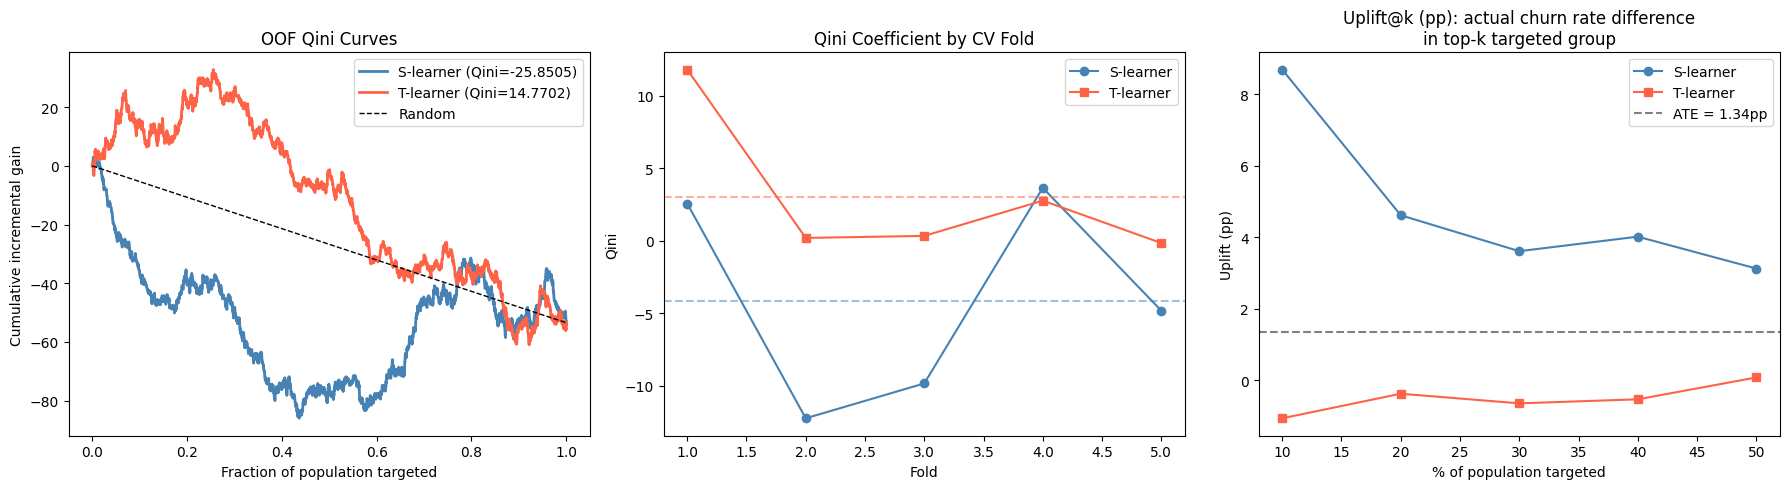

        Metric  S-learner  T-learner
      OOF Qini   -25.8505    14.7702
CV Qini (mean)    -4.1419     2.9915
 CV Qini (std)     7.1528     5.0679
    Uplift@20%     0.0376    -0.0027
    Uplift@30%     0.0296    -0.0021

Selected: T-learner (higher OOF Qini)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Qini curves ---
ax = axes[0]
xs, qs = qini_curve(y.values, oof_uplift_s, w.values)
xt, qt = qini_curve(y.values, oof_uplift_t, w.values)
rnd_q, rnd_x = random_qini(y.values, w.values)

ax.plot(xs, qs, color='steelblue', linewidth=2,
        label=f'S-learner (Qini={oof_qini_s:.4f})')
ax.plot(xt, qt, color='tomato',    linewidth=2,
        label=f'T-learner (Qini={oof_qini_t:.4f})')
ax.plot(rnd_x, rnd_q, 'k--', linewidth=1, label='Random')
ax.set_title('OOF Qini Curves')
ax.set_xlabel('Fraction of population targeted')
ax.set_ylabel('Cumulative incremental gain')
ax.legend()

# --- CV Qini by fold ---
ax = axes[1]
x = np.arange(1, 6)
ax.plot(x, s_res.qini, 'o-', color='steelblue', label='S-learner')
ax.plot(x, t_res.qini, 's-', color='tomato',    label='T-learner')
ax.axhline(s_res.qini.mean(), color='steelblue', linestyle='--', alpha=0.5)
ax.axhline(t_res.qini.mean(), color='tomato',    linestyle='--', alpha=0.5)
ax.set_title('Qini Coefficient by CV Fold')
ax.set_xlabel('Fold')
ax.set_ylabel('Qini')
ax.legend()

# --- Uplift@k comparison ---
ax = axes[2]
k_vals = [0.10, 0.20, 0.30, 0.40, 0.50]
s_at_k = [uplift_at_k(y.values, oof_uplift_s, w.values, k) for k in k_vals]
t_at_k = [uplift_at_k(y.values, oof_uplift_t, w.values, k) for k in k_vals]
ate    = float(y[w == 0].mean() - y[w == 1].mean())

ax.plot([k*100 for k in k_vals], [u*100 for u in s_at_k],
        'o-', color='steelblue', label='S-learner')
ax.plot([k*100 for k in k_vals], [u*100 for u in t_at_k],
        's-', color='tomato', label='T-learner')
ax.axhline(ate * 100, color='gray', linestyle='--', label=f'ATE = {ate*100:.2f}pp')
ax.set_title('Uplift@k (pp): actual churn rate difference\nin top-k targeted group')
ax.set_xlabel('% of population targeted')
ax.set_ylabel('Uplift (pp)')
ax.legend()

plt.tight_layout()
plt.savefig('uplift_model_comparison.png', dpi=120)
plt.show()

# Summary table
summary = pd.DataFrame({
    'Metric':     ['OOF Qini', 'CV Qini (mean)', 'CV Qini (std)', 'Uplift@20%', 'Uplift@30%'],
    'S-learner':  [oof_qini_s, s_res.qini.mean(), s_res.qini.std(),
                   s_res.uplift_top20.mean(), s_res.uplift_top30.mean()],
    'T-learner':  [oof_qini_t, t_res.qini.mean(), t_res.qini.std(),
                   t_res.uplift_top20.mean(), t_res.uplift_top30.mean()],
})
print(summary.round(4).to_string(index=False))

best = 'T-learner' if oof_qini_t > oof_qini_s else 'S-learner'
print(f"\nSelected: {best} (higher OOF Qini)")

## 5. Final Models — Train on All Data

We train both final models on all 10,000 train members.  
The selected model (higher Qini) is used to score test members.

In [6]:
# Final S-learner
final_s = lgb.LGBMClassifier(**{**LGB_BASE, 'n_estimators': int(s_res['best_iter'].mean())})
final_s.fit(X_full, y, callbacks=[lgb.log_evaluation(-1)])
print("Final S-learner trained.")

# Final T-learner
ctrl_mask_all = w == 0
trt_mask_all  = w == 1

final_t0 = lgb.LGBMClassifier(**LGB_T)
final_t0.fit(X_base[ctrl_mask_all], y[ctrl_mask_all], callbacks=[lgb.log_evaluation(-1)])

final_t1 = lgb.LGBMClassifier(**LGB_T)
final_t1.fit(X_base[trt_mask_all], y[trt_mask_all], callbacks=[lgb.log_evaluation(-1)])

print(f"Final T0 (control model) trained on {ctrl_mask_all.sum():,} members")
print(f"Final T1 (treated model) trained on {trt_mask_all.sum():,} members")

Final S-learner trained.


Final T0 (control model) trained on 6,016 members
Final T1 (treated model) trained on 3,984 members


## 6. Feature Importance

Comparing T0 (control) vs T1 (treated) feature importance reveals which features  
drive churn differently for each group — the source of treatment effect heterogeneity.

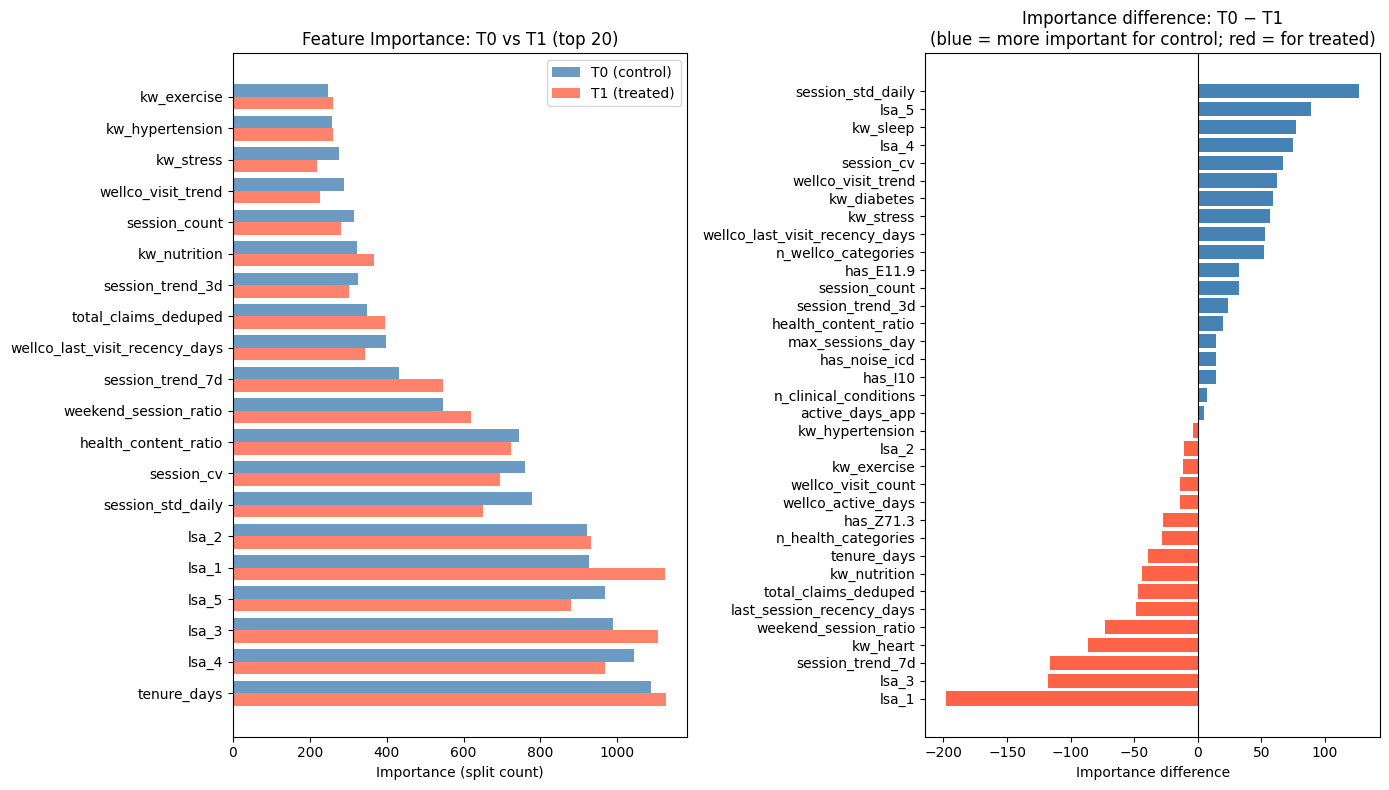

Top 10 features by T0 importance:
                       T0 (control)  T1 (treated)  diff
tenure_days                    1087          1126   -39
lsa_4                          1043           968    75
lsa_3                           988          1106  -118
lsa_5                           969           880    89
lsa_1                           926          1124  -198
lsa_2                           920           931   -11
session_std_daily               777           650   127
session_cv                      761           694    67
health_content_ratio            744           724    20
weekend_session_ratio           547           620   -73


In [7]:
imp_t0 = pd.Series(final_t0.feature_importances_, index=FEAT_COLS, name='T0 (control)')
imp_t1 = pd.Series(final_t1.feature_importances_, index=FEAT_COLS, name='T1 (treated)')
imp_df = pd.concat([imp_t0, imp_t1], axis=1)
imp_df['diff'] = imp_df['T0 (control)'] - imp_df['T1 (treated)']
imp_df = imp_df.sort_values('T0 (control)', ascending=False)

top_n = 20
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Side-by-side importance
top_feats = imp_df.head(top_n).index
x = np.arange(len(top_feats))
width = 0.4
axes[0].barh(x + width/2, imp_df.loc[top_feats, 'T0 (control)'], width,
             color='steelblue', alpha=0.8, label='T0 (control)')
axes[0].barh(x - width/2, imp_df.loc[top_feats, 'T1 (treated)'], width,
             color='tomato', alpha=0.8, label='T1 (treated)')
axes[0].set_yticks(x)
axes[0].set_yticklabels(top_feats)
axes[0].set_title(f'Feature Importance: T0 vs T1 (top {top_n})')
axes[0].set_xlabel('Importance (split count)')
axes[0].legend()

# Importance difference (positive = more important in control model)
diff_sorted = imp_df['diff'].sort_values()
colors = ['tomato' if v < 0 else 'steelblue' for v in diff_sorted]
axes[1].barh(diff_sorted.index, diff_sorted.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Importance difference: T0 − T1\n(blue = more important for control; red = for treated)')
axes[1].set_xlabel('Importance difference')

plt.tight_layout()
plt.savefig('uplift_feature_importance.png', dpi=120)
plt.show()

print("Top 10 features by T0 importance:")
print(imp_df[['T0 (control)', 'T1 (treated)', 'diff']].head(10).round(1))

## 7. Uplift Score Distribution (Train)

Validates that the model produces a spread of predicted uplift, with the treated group  
correctly receiving higher predicted uplift scores than control.

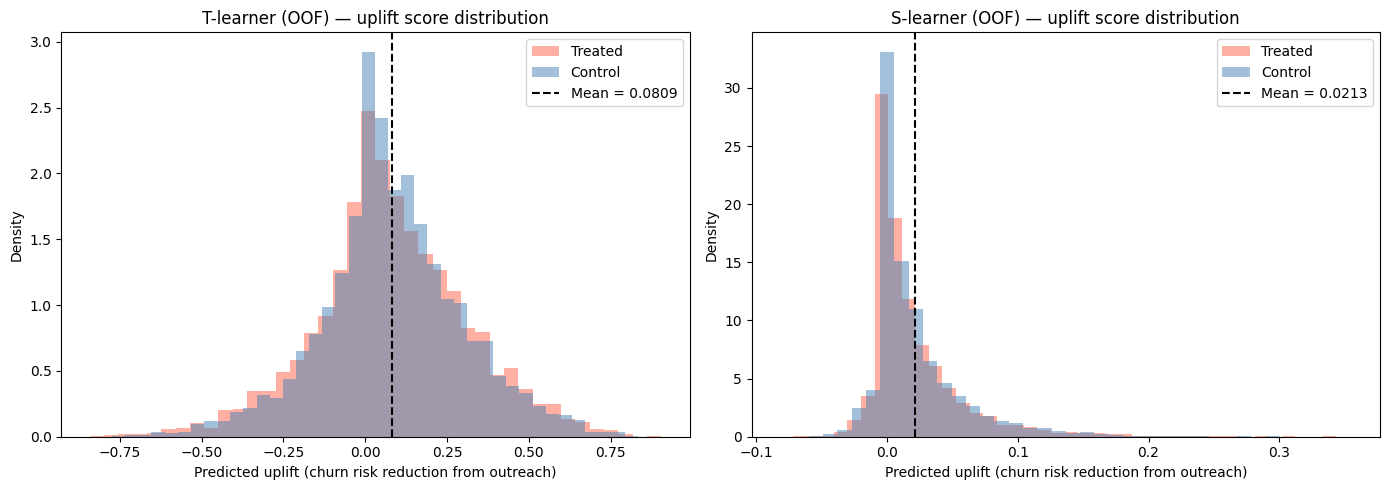

T-learner OOF uplift summary:
count    10000.0000
mean         0.0809
std          0.2240
min         -0.8418
25%         -0.0397
50%          0.0658
75%          0.2135
max          0.9046
dtype: float64

Members with positive predicted uplift: 66.7%
Mean uplift in top 20%: 0.3996


In [8]:
# T-learner uplift on train (in-sample — just for distribution visualization)
train_uplift_t = final_t0.predict_proba(X_base)[:, 1] - final_t1.predict_proba(X_base)[:, 1]
train_uplift_s_insample = (final_s.predict_proba(X_full.assign(outreach=0))[:, 1] -
                           final_s.predict_proba(X_full.assign(outreach=1))[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (uplift, name, color) in zip(axes, [
    (oof_uplift_t, 'T-learner (OOF)', 'tomato'),
    (oof_uplift_s, 'S-learner (OOF)', 'steelblue')
]):
    for grp, lbl, c in [(w==1, 'Treated', 'tomato'), (w==0, 'Control', 'steelblue')]:
        ax.hist(uplift[grp.values], bins=40, alpha=0.5, density=True, color=c, label=lbl)
    ax.axvline(uplift.mean(), color='black', linestyle='--',
               label=f'Mean = {uplift.mean():.4f}')
    ax.set_title(f'{name} — uplift score distribution')
    ax.set_xlabel('Predicted uplift (churn risk reduction from outreach)')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.savefig('uplift_score_distribution.png', dpi=120)
plt.show()

print("T-learner OOF uplift summary:")
print(pd.Series(oof_uplift_t).describe().round(4))
print(f"\nMembers with positive predicted uplift: {(oof_uplift_t > 0).mean():.1%}")
print(f"Mean uplift in top 20%: {oof_uplift_t[oof_uplift_t >= np.percentile(oof_uplift_t, 80)].mean():.4f}")

## 8. Score Test Members & Save Predictions

Score test members using the selected final model (higher OOF Qini).  
Rank by predicted uplift descending — rank 1 = member most likely to churn without outreach *and* most likely to be saved by it.

In [9]:
X_test = test[FEAT_COLS]

# T-learner scores
t_uplift_test  = final_t0.predict_proba(X_test)[:, 1] - final_t1.predict_proba(X_test)[:, 1]
t_churn_risk   = final_t0.predict_proba(X_test)[:, 1]  # P(churn | no outreach)

# S-learner scores
X_test_s0 = X_test.copy(); X_test_s0['outreach'] = 0
X_test_s1 = X_test.copy(); X_test_s1['outreach'] = 1
s_uplift_test = (final_s.predict_proba(X_test_s0)[:, 1] -
                 final_s.predict_proba(X_test_s1)[:, 1])

# Use the model with higher OOF Qini
if oof_qini_t >= oof_qini_s:
    primary_uplift = t_uplift_test
    primary_model  = 'T-learner'
else:
    primary_uplift = s_uplift_test
    primary_model  = 'S-learner'

print(f"Primary model: {primary_model} (OOF Qini: T={oof_qini_t:.4f}, S={oof_qini_s:.4f})")

predictions = pd.DataFrame({
    'member_id':          test['member_id'],
    'uplift_score':       primary_uplift,
    'churn_risk':         t_churn_risk,          # P(churn | no outreach) from T0
    't_uplift_score':     t_uplift_test,          # T-learner uplift
    's_uplift_score':     s_uplift_test,          # S-learner uplift
    'rank':               pd.Series(primary_uplift).rank(ascending=False, method='first').astype(int)
}).sort_values('rank').reset_index(drop=True)

print(f"\nTest uplift score distribution ({primary_model}):")
print(predictions['uplift_score'].describe().round(4))
print(f"\nTop 10 members by predicted uplift:")
print(predictions[['member_id','uplift_score','churn_risk','rank']].head(10).to_string(index=False))

predictions.to_csv('predictions_uplift.csv', index=False)
print(f"\nSaved predictions_uplift.csv ({len(predictions):,} rows)")

Primary model: T-learner (OOF Qini: T=14.7702, S=-25.8505)

Test uplift score distribution (T-learner):
count    10000.0000
mean         0.0989
std          0.2109
min         -0.8216
25%         -0.0176
50%          0.0910
75%          0.2294
max          0.8897
Name: uplift_score, dtype: float64

Top 10 members by predicted uplift:
 member_id  uplift_score  churn_risk  rank
     29146      0.889654    0.894720     1
     24472      0.851870    0.929324     2
     26652      0.830252    0.834990     3
     28477      0.806758    0.842005     4
     23142      0.798088    0.848826     5
     25957      0.781318    0.856211     6
     29354      0.774650    0.881765     7
     20466      0.773633    0.973687     8
     21284      0.767437    0.774775     9
     27186      0.764190    0.783623    10

Saved predictions_uplift.csv (10,000 rows)


## 9. Outreach Sizing (Uplift-Based)

The previous outreach sizing (Phase 4) was cost-benefit on churn risk.  
The uplift-based sizing targets members by predicted treatment effect.  
The optimal n is where marginal uplift from the next-ranked member falls below the cost threshold.

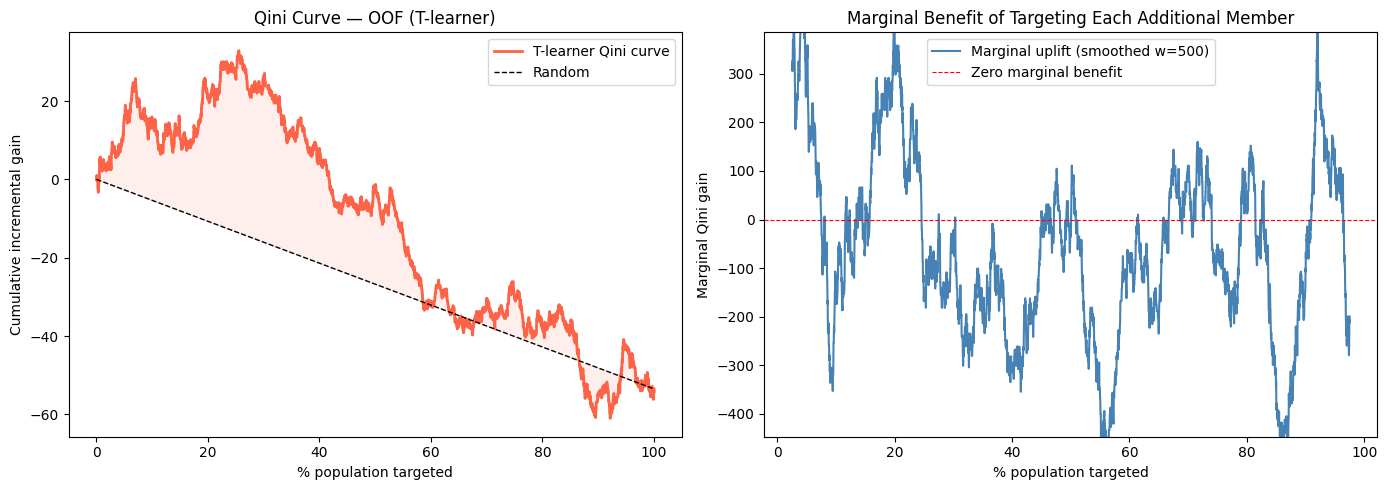

Optimal outreach fraction (marginal Qini = 0): 7.47%
Optimal n for 10,000 test members: 747
  Top 10% (1,000 members): observed uplift = -1.06pp
  Top 20% (2,000 members): observed uplift = -0.38pp
  Top 30% (3,000 members): observed uplift = -0.65pp
  Top 40% (4,000 members): observed uplift = -0.53pp
  Top 50% (5,000 members): observed uplift = 0.08pp


In [10]:
# Sort OOF uplift predictions by predicted uplift rank
train_scored = pd.DataFrame({
    'uplift_pred': oof_uplift_t,
    'churn':       y.values,
    'outreach':    w.values
}).sort_values('uplift_pred', ascending=False).reset_index(drop=True)

# Cumulative Qini curve on OOF predictions
xs, qs = qini_curve(y.values, oof_uplift_t, w.values)
# Marginal benefit: first derivative of Qini curve
marginal = np.gradient(qs, xs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(xs * 100, qs, color='tomato', linewidth=2, label='T-learner Qini curve')
rnd_q, rnd_x = random_qini(y.values, w.values)
ax.plot(rnd_x * 100, rnd_q, 'k--', linewidth=1, label='Random')
ax.fill_between(xs * 100, rnd_q, qs, alpha=0.1, color='tomato')
ax.set_title('Qini Curve — OOF (T-learner)')
ax.set_xlabel('% population targeted')
ax.set_ylabel('Cumulative incremental gain')
ax.legend()

ax = axes[1]
# Rolling window smoothed marginal uplift
window = 500
smooth_marginal = pd.Series(marginal).rolling(window, center=True).mean()
ax.plot(xs * 100, smooth_marginal, color='steelblue', linewidth=1.5,
        label=f'Marginal uplift (smoothed w={window})')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Zero marginal benefit')
ax.set_title('Marginal Benefit of Targeting Each Additional Member')
ax.set_xlabel('% population targeted')
ax.set_ylabel('Marginal Qini gain')
ax.legend()
ax.set_ylim(smooth_marginal.quantile(0.01), smooth_marginal.quantile(0.99))

plt.tight_layout()
plt.savefig('uplift_sizing.png', dpi=120)
plt.show()

# Optimal n: where marginal benefit drops below zero
smooth_arr = smooth_marginal.bfill().ffill().values
crossings = np.where(np.diff(np.sign(smooth_arr)))[0]
if len(crossings) > 0:
    optimal_frac = xs[crossings[0]]
    optimal_n    = int(10000 * optimal_frac)
    print(f"Optimal outreach fraction (marginal Qini = 0): {optimal_frac:.2%}")
    print(f"Optimal n for 10,000 test members: {optimal_n:,}")
else:
    print("Marginal benefit positive throughout — target a larger fraction or use cost-benefit threshold")

# Uplift at different targeting rates
for pct in [0.10, 0.20, 0.30, 0.40, 0.50]:
    u = uplift_at_k(y.values, oof_uplift_t, w.values, k=pct)
    n = int(len(y) * pct)
    print(f"  Top {pct:.0%} ({n:,} members): observed uplift = {u*100:.2f}pp")

## 10. Summary

In [11]:
print("=" * 65)
print("UPLIFT MODEL RESULTS")
print("=" * 65)
print(f"")
print(f"Architecture       S-learner    T-learner")
print(f"-" * 45)
print(f"OOF Qini           {oof_qini_s:.4f}       {oof_qini_t:.4f}")
print(f"CV Qini (mean)     {s_res.qini.mean():.4f}       {t_res.qini.mean():.4f}")
print(f"CV Qini (std)      {s_res.qini.std():.4f}       {t_res.qini.std():.4f}")
print(f"Uplift@20%         {s_res.uplift_top20.mean():.4f}       {t_res.uplift_top20.mean():.4f}")
print(f"Uplift@30%         {s_res.uplift_top30.mean():.4f}       {t_res.uplift_top30.mean():.4f}")
print(f"")
print(f"Selected model: {primary_model}")
print(f"")
print(f"Metric rationale:")
print(f"  • Qini coefficient: primary uplift metric (area above random baseline)")
print(f"  • AUUC: absolute incremental gain, useful for capacity planning")
print(f"  • Uplift@k: sanity check — do top-ranked members actually respond better?")
print(f"")
print(f"Outreach treatment handling:")
print(f"  • S-learner: outreach included as feature; flipped at score time")
print(f"  • T-learner: outreach used only to split training set; not a feature")
print(f"  • Test members scored on uplift (benefit from outreach), not churn risk")
print(f"")
print(f"Output: predictions_uplift.csv — {len(predictions):,} test members ranked by uplift_score")

UPLIFT MODEL RESULTS

Architecture       S-learner    T-learner
---------------------------------------------
OOF Qini           -25.8505       14.7702
CV Qini (mean)     -4.1419       2.9915
CV Qini (std)      7.1528       5.0679
Uplift@20%         0.0376       -0.0027
Uplift@30%         0.0296       -0.0021

Selected model: T-learner

Metric rationale:
  • Qini coefficient: primary uplift metric (area above random baseline)
  • AUUC: absolute incremental gain, useful for capacity planning
  • Uplift@k: sanity check — do top-ranked members actually respond better?

Outreach treatment handling:
  • S-learner: outreach included as feature; flipped at score time
  • T-learner: outreach used only to split training set; not a feature
  • Test members scored on uplift (benefit from outreach), not churn risk

Output: predictions_uplift.csv — 10,000 test members ranked by uplift_score
